# Détection des feux de forêt avec ConvNeXt V2 Tiny

**Projet :** Classification binaire des images en `fire` et `nofire`  
**Noms des étudiantes :** [Nom 1] — [Nom 2] — [Nom 3]  
**Encadrant(e) :** [Nom de l’encadrant(e)]  
**Date :** [Date de présentation]

Ce notebook présente un modèle CNN moderne basé sur **ConvNeXt V2 Tiny pré-entraîné** pour détecter la présence de feu dans des images.


## Importation des bibliothèques
Installation et importation des bibliothèques nécessaires.


In [4]:
import os
import time
import random
import shutil
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms

import timm
from timm.data import resolve_model_data_config

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Drive non monté automatiquement :", e)

print("PyTorch:", torch.__version__)
print("timm:", timm.__version__)
print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch: 2.10.0+cu128
timm: 1.0.26
CUDA disponible: True
GPU: Tesla T4


## Préparation des données
Configuration des chemins, copie de la dataset, création du split train/validation et définition des transformations.


In [5]:
DATASET_DIR_DRIVE = "/content/drive/MyDrive/TP7+projet/Forest Fire Dataset"

COPY_TO_LOCAL = True
LOCAL_DATASET_DIR = "/content/Forest Fire Dataset"

PROJECT_DIR_DRIVE = "/content/drive/MyDrive/TP7+projet/ConvNeXtV2_Tiny_Forest_Fire"
MODELS_DIR = os.path.join(PROJECT_DIR_DRIVE, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR_DRIVE, "results")
FIGURES_DIR = os.path.join(PROJECT_DIR_DRIVE, "figures")
PREDICTIONS_DIR = os.path.join(PROJECT_DIR_DRIVE, "predictions")

for d in [PROJECT_DIR_DRIVE, MODELS_DIR, RESULTS_DIR, FIGURES_DIR, PREDICTIONS_DIR]:
    os.makedirs(d, exist_ok=True)

SEED = 42
VAL_RATIO = 0.20

# Réduire à 8 si la mémoire GPU est insuffisante.
BATCH_SIZE = 16
NUM_WORKERS = 2

# Taille standard pour ConvNeXt V2 Tiny.

IMAGE_SIZE = 224

USE_AMP = True

# Paramètres d’entraînement.
HEAD_EPOCHS = 3
FINE_EPOCHS = 7

LR_HEAD = 5e-4
LR_FINE = 1e-5
WEIGHT_DECAY = 1e-5
DROPOUT = 0.20
LABEL_SMOOTHING = 0.00

# Fine-tuning limité pour réduire l’overfitting.

UNFREEZE_STAGES = 2

PATIENCE = 4
DEFAULT_THRESHOLD = 0.50

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Dossier résultats:", PROJECT_DIR_DRIVE)


Device: cuda
Dossier résultats: /content/drive/MyDrive/TP7+projet/ConvNeXtV2_Tiny_Forest_Fire


In [6]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)


In [7]:
def copy_dataset_to_local(src, dst):
    src = Path(src)
    dst = Path(dst)

    if not src.exists():
        raise FileNotFoundError(f"Dataset introuvable : {src}")

    if dst.exists():
        print("Dataset déjà copiée :", dst)
        return str(dst)

    print("Copie de la dataset vers /content ...")
    ignore_patterns = shutil.ignore_patterns(
        "*results*",
        "ConvNeXtV2_Tiny_Forest_Fire",
        "__MACOSX",
        ".ipynb_checkpoints"
    )
    shutil.copytree(src, dst, ignore=ignore_patterns)
    print("Copie terminée :", dst)
    return str(dst)

if COPY_TO_LOCAL:
    DATASET_DIR = copy_dataset_to_local(DATASET_DIR_DRIVE, LOCAL_DATASET_DIR)
else:
    DATASET_DIR = DATASET_DIR_DRIVE

TRAINING_DIR = os.path.join(DATASET_DIR, "Training")
TESTING_DIR = os.path.join(DATASET_DIR, "Testing")

print("DATASET_DIR:", DATASET_DIR)
print("TRAINING_DIR existe:", os.path.exists(TRAINING_DIR))
print("TESTING_DIR existe:", os.path.exists(TESTING_DIR))


Copie de la dataset vers /content ...
Copie terminée : /content/Forest Fire Dataset
DATASET_DIR: /content/Forest Fire Dataset
TRAINING_DIR existe: True
TESTING_DIR existe: True


In [8]:
IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def is_image_file(path):
    return Path(path).suffix.lower() in IMG_EXTENSIONS

def label_from_parent(path):
    parent = Path(path).parent.name.lower().replace(" ", "").replace("-", "").replace("_", "")

    # Important : tester nofire avant fire, car "nofire" contient "fire".
    if parent in ["nofire", "nonfire", "no"]:
        return 0
    if parent in ["fire", "fires", "flame", "flames"]:
        return 1

    if "nofire" in parent or "nonfire" in parent:
        return 0
    if "fire" in parent:
        return 1

    return None

def collect_labeled_images(training_dir):
    paths, labels = [], []

    for root, dirs, files in os.walk(training_dir):
        for f in files:
            p = os.path.join(root, f)
            if is_image_file(p):
                y = label_from_parent(p)
                if y is not None:
                    paths.append(p)
                    labels.append(y)

    return np.array(paths), np.array(labels)

all_paths, all_labels = collect_labeled_images(TRAINING_DIR)

print("Nombre total d'images Training:", len(all_paths))
print("fire:", int(np.sum(all_labels == 1)))
print("nofire:", int(np.sum(all_labels == 0)))

if len(all_paths) == 0:
    raise ValueError("Aucune image trouvée. Vérifie Training/fire et Training/nofire")

train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=VAL_RATIO,
    stratify=all_labels,
    random_state=SEED
)

print("\nSplit :")
print("Train:", len(train_paths), "| fire:", int(np.sum(train_labels == 1)), "| nofire:", int(np.sum(train_labels == 0)))
print("Val  :", len(val_paths), "| fire:", int(np.sum(val_labels == 1)), "| nofire:", int(np.sum(val_labels == 0)))

split_df = pd.DataFrame({
    "path": np.concatenate([train_paths, val_paths]),
    "label": np.concatenate([train_labels, val_labels]),
    "label_name": ["fire" if y == 1 else "nofire" for y in np.concatenate([train_labels, val_labels])],
    "split": ["train"] * len(train_paths) + ["val"] * len(val_paths)
})

split_path = os.path.join(RESULTS_DIR, "train_val_split.csv")
split_df.to_csv(split_path, index=False)
print("Split sauvegardé :", split_path)


Nombre total d'images Training: 1520
fire: 760
nofire: 760

Split :
Train: 1216 | fire: 608 | nofire: 608
Val  : 304 | fire: 152 | nofire: 152
Split sauvegardé : /content/drive/MyDrive/TP7+projet/ConvNeXtV2_Tiny_Forest_Fire/results/train_val_split.csv


In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class ForestFireDataset(Dataset):
    def __init__(self, paths, labels=None, transform=None):
        self.paths = list(paths)
        self.labels = None if labels is None else list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        if self.labels is None:
            return img, path

        y = torch.tensor(float(self.labels[idx]), dtype=torch.float32)
        return img, y

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.10, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = ForestFireDataset(train_paths, train_labels, transform=train_transform)
val_ds = ForestFireDataset(val_paths, val_labels, transform=val_transform)

class_counts = np.bincount(train_labels.astype(int), minlength=2)
class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = [class_weights[int(y)] for y in train_labels]

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("class_counts:", class_counts)
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


class_counts: [608 608]
Train batches: 76
Val batches: 19


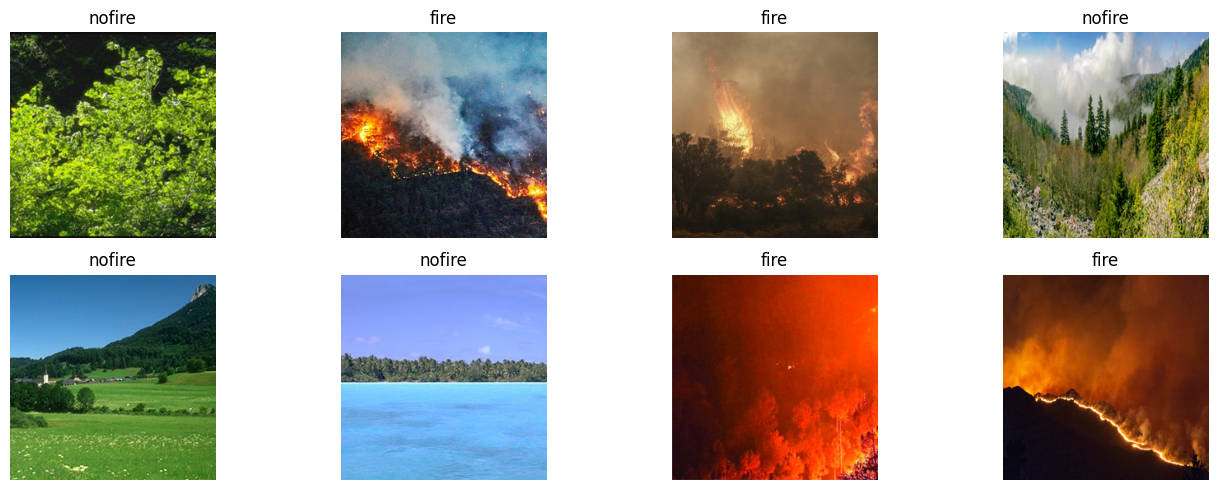

In [10]:
def show_samples(n=8):
    idxs = np.random.choice(len(all_paths), size=min(n, len(all_paths)), replace=False)

    plt.figure(figsize=(14, 5))
    for i, idx in enumerate(idxs):
        img = Image.open(all_paths[idx]).convert("RGB")
        label = "fire" if all_labels[idx] == 1 else "nofire"

        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples()


## Construction du modèle CNN
Création du modèle **ConvNeXt V2 Tiny** et adaptation de la dernière couche pour une classification binaire.


In [11]:
# Sélection automatique d’une variante ConvNeXt V2 disponible.

MODEL_NAME_CANDIDATES = [
    "convnextv2_tiny.fcmae_ft_in22k_in1k",
    "convnextv2_tiny.fcmae_ft_in1k",
    "convnextv2_tiny",
]

print("Modèles ConvNeXt V2 disponibles dans timm :")
available = timm.list_models("convnextv2*", pretrained=True)
print(available[:20], "... total:", len(available))

def create_convnextv2_tiny(dropout=0.20):
    last_error = None

    for model_name in MODEL_NAME_CANDIDATES:
        try:
            print("Essai du modèle :", model_name)
            model = timm.create_model(
                model_name,
                pretrained=True,
                num_classes=1,
                drop_rate=dropout
            )
            print("Modèle chargé :", model_name)
            return model, model_name
        except Exception as e:
            print("Échec :", model_name, "|", e)
            last_error = e

    raise RuntimeError(f"Aucun modèle ConvNeXt V2 Tiny n'a pu être chargé. Dernière erreur : {last_error}")

model, MODEL_NAME_USED = create_convnextv2_tiny(dropout=DROPOUT)
model = model.to(DEVICE)

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total, trainable = count_parameters(model)
print("\nConvNeXt V2 Tiny créé.")
print("MODEL_NAME_USED:", MODEL_NAME_USED)
print("Total paramètres:", f"{total:,}")
print("Paramètres entraînables:", f"{trainable:,}")


Modèles ConvNeXt V2 disponibles dans timm :
['convnextv2_atto.fcmae', 'convnextv2_atto.fcmae_ft_in1k', 'convnextv2_base.fcmae', 'convnextv2_base.fcmae_ft_in1k', 'convnextv2_base.fcmae_ft_in22k_in1k', 'convnextv2_base.fcmae_ft_in22k_in1k_384', 'convnextv2_femto.fcmae', 'convnextv2_femto.fcmae_ft_in1k', 'convnextv2_huge.fcmae', 'convnextv2_huge.fcmae_ft_in1k', 'convnextv2_huge.fcmae_ft_in22k_in1k_384', 'convnextv2_huge.fcmae_ft_in22k_in1k_512', 'convnextv2_large.fcmae', 'convnextv2_large.fcmae_ft_in1k', 'convnextv2_large.fcmae_ft_in22k_in1k', 'convnextv2_large.fcmae_ft_in22k_in1k_384', 'convnextv2_nano.fcmae', 'convnextv2_nano.fcmae_ft_in1k', 'convnextv2_nano.fcmae_ft_in22k_in1k', 'convnextv2_nano.fcmae_ft_in22k_in1k_384'] ... total: 26
Essai du modèle : convnextv2_tiny.fcmae_ft_in22k_in1k


model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

Modèle chargé : convnextv2_tiny.fcmae_ft_in22k_in1k

ConvNeXt V2 Tiny créé.
MODEL_NAME_USED: convnextv2_tiny.fcmae_ft_in22k_in1k
Total paramètres: 27,867,265
Paramètres entraînables: 27,867,265


In [12]:
def set_requires_grad(module, value):
    for p in module.parameters():
        p.requires_grad = value

def get_head_module(model):
    # ConvNeXt V2 timm utilise généralement model.head
    if hasattr(model, "head"):
        return model.head
    # fallback
    classifier = model.get_classifier()
    return classifier

def prepare_head_training(model):
    # Geler tout le modèle.
    set_requires_grad(model, False)

    # Dégeler seulement la tête.
    head = get_head_module(model)
    set_requires_grad(head, True)

def prepare_fine_tuning(model, unfreeze_stages=2):
    # Geler tout le modèle.
    set_requires_grad(model, False)

    # Tête toujours entraînable.
    head = get_head_module(model)
    set_requires_grad(head, True)

    # Dégeler les derniers stages si présents.
    if hasattr(model, "stages"):
        for stage in list(model.stages)[-unfreeze_stages:]:
            set_requires_grad(stage, True)
    elif hasattr(model, "features"):
        for block in list(model.features)[-unfreeze_stages:]:
            set_requires_grad(block, True)
    else:
        # fallback : dégeler les derniers modules enfants
        children = list(model.children())
        for child in children[-unfreeze_stages:]:
            set_requires_grad(child, True)

prepare_head_training(model)
total, trainable = count_parameters(model)
print("Après freeze head-training:")
print("Paramètres entraînables:", f"{trainable:,}", "/", f"{total:,}")


Après freeze head-training:
Paramètres entraînables: 2,305 / 27,867,265


## Entraînement
Entraînement en deux phases : d’abord la tête de classification, puis le fine-tuning partiel du modèle.


In [13]:
def compute_pos_weight(labels):
    labels = np.array(labels).astype(int)
    n_pos = np.sum(labels == 1)
    n_neg = np.sum(labels == 0)
    return torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32)

POS_WEIGHT = compute_pos_weight(train_labels).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)

print("POS_WEIGHT:", POS_WEIGHT.item())

def smooth_binary_targets(y, eps):
    if eps <= 0:
        return y
    return y * (1.0 - eps) + 0.5 * eps

def run_one_epoch(model, loader, criterion, optimizer=None, scaler=None, label_smoothing=0.0):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    losses = []
    probs_all = []
    y_all = []

    for images, targets in loader:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True).view(-1, 1)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
                logits = model(images)
                if logits.ndim == 1:
                    logits = logits.view(-1, 1)

                targets_for_loss = smooth_binary_targets(targets, label_smoothing)
                loss = criterion(logits, targets_for_loss)

            if is_train:
                if scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

        losses.append(loss.item() * images.size(0))

        probs = torch.sigmoid(logits.detach()).cpu().numpy().reshape(-1)
        probs_all.extend(probs.tolist())
        y_all.extend(targets.detach().cpu().numpy().reshape(-1).astype(int).tolist())

    avg_loss = np.sum(losses) / len(loader.dataset)
    probs_all = np.array(probs_all)
    y_all = np.array(y_all)
    preds = (probs_all >= DEFAULT_THRESHOLD).astype(int)

    metrics = {
        "loss": avg_loss,
        "accuracy": accuracy_score(y_all, preds),
        "precision_fire": precision_score(y_all, preds, zero_division=0),
        "recall_fire": recall_score(y_all, preds, zero_division=0),
        "f1_fire": f1_score(y_all, preds, zero_division=0),
    }

    try:
        metrics["auc"] = roc_auc_score(y_all, probs_all)
    except Exception:
        metrics["auc"] = np.nan

    return metrics, y_all, probs_all

def optimize_threshold(y_true, probs):
    rows = []
    thresholds = np.round(np.arange(0.05, 0.96, 0.01), 2)

    for th in thresholds:
        preds = (probs >= th).astype(int)

        cm = confusion_matrix(y_true, preds, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        rows.append({
            "threshold": th,
            "accuracy": accuracy_score(y_true, preds),
            "precision_fire": precision_score(y_true, preds, zero_division=0),
            "recall_fire": recall_score(y_true, preds, zero_division=0),
            "f1_fire": f1_score(y_true, preds, zero_division=0),
            "false_negative_fire": fn,
            "false_positive_fire": fp,
        })

    df = pd.DataFrame(rows)

    # Pour ce projet, on favorise le F1 et surtout recall_fire.
    df = df.sort_values(
        by=["f1_fire", "recall_fire", "accuracy", "false_negative_fire"],
        ascending=[False, False, False, True]
    )

    return df.iloc[0].to_dict(), df


POS_WEIGHT: 1.0


In [14]:
history = []

best_val_loss = float("inf")
best_state = None
best_epoch = -1
patience_counter = 0

scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and DEVICE.type == "cuda"))

start_time = time.time()
epoch_index = 0

# -------------------------
# Phase 1 : classifier head
# -------------------------
prepare_head_training(model)

optimizer = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR_HEAD,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.4,
    patience=2
)

print("\nPHASE 1 : entraînement de la tête de classification")
print("LR_HEAD:", LR_HEAD)

for epoch in range(HEAD_EPOCHS):
    epoch_index += 1

    train_m, _, _ = run_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer=optimizer,
        scaler=scaler,
        label_smoothing=LABEL_SMOOTHING
    )

    val_m, y_val, probs_val = run_one_epoch(
        model,
        val_loader,
        criterion,
        optimizer=None,
        scaler=None,
        label_smoothing=0.0
    )

    scheduler.step(val_m["loss"])

    row = {
        "epoch": epoch_index,
        "phase": "head",
        "train_loss": train_m["loss"],
        "train_accuracy": train_m["accuracy"],
        "train_precision_fire": train_m["precision_fire"],
        "train_recall_fire": train_m["recall_fire"],
        "train_f1_fire": train_m["f1_fire"],
        "train_auc": train_m["auc"],
        "val_loss": val_m["loss"],
        "val_accuracy": val_m["accuracy"],
        "val_precision_fire": val_m["precision_fire"],
        "val_recall_fire": val_m["recall_fire"],
        "val_f1_fire": val_m["f1_fire"],
        "val_auc": val_m["auc"],
        "lr": optimizer.param_groups[0]["lr"],
    }

    history.append(row)

    print(
        f"Epoch {epoch_index:02d} [head] "
        f"train_loss={train_m['loss']:.4f} train_acc={train_m['accuracy']:.4f} | "
        f"val_loss={val_m['loss']:.4f} val_acc={val_m['accuracy']:.4f} "
        f"val_f1={val_m['f1_fire']:.4f} val_recall_fire={val_m['recall_fire']:.4f}"
    )

    if val_m["loss"] < best_val_loss:
        best_val_loss = val_m["loss"]
        best_epoch = epoch_index
        best_state = {
            "model_state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "threshold": DEFAULT_THRESHOLD,
            "config": {
                "model": "convnextv2_tiny",
                "model_name_used": MODEL_NAME_USED,
                "image_size": IMAGE_SIZE,
                "batch_size": BATCH_SIZE,
                "lr_head": LR_HEAD,
                "lr_fine": LR_FINE,
                "weight_decay": WEIGHT_DECAY,
                "dropout": DROPOUT,
                "label_smoothing": LABEL_SMOOTHING,
                "unfreeze_stages": UNFREEZE_STAGES,
            }
        }
        patience_counter = 0
    else:
        patience_counter += 1

# -------------------------
# Phase 2 : fine-tuning
# -------------------------
prepare_fine_tuning(model, unfreeze_stages=UNFREEZE_STAGES)

optimizer = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR_FINE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.4,
    patience=2
)

total, trainable = count_parameters(model)
print("\nPHASE 2 : fine-tuning")
print("LR_FINE:", LR_FINE)
print("Paramètres entraînables:", f"{trainable:,}", "/", f"{total:,}")

for epoch in range(FINE_EPOCHS):
    epoch_index += 1

    train_m, _, _ = run_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer=optimizer,
        scaler=scaler,
        label_smoothing=LABEL_SMOOTHING
    )

    val_m, y_val, probs_val = run_one_epoch(
        model,
        val_loader,
        criterion,
        optimizer=None,
        scaler=None,
        label_smoothing=0.0
    )

    scheduler.step(val_m["loss"])

    row = {
        "epoch": epoch_index,
        "phase": "fine",
        "train_loss": train_m["loss"],
        "train_accuracy": train_m["accuracy"],
        "train_precision_fire": train_m["precision_fire"],
        "train_recall_fire": train_m["recall_fire"],
        "train_f1_fire": train_m["f1_fire"],
        "train_auc": train_m["auc"],
        "val_loss": val_m["loss"],
        "val_accuracy": val_m["accuracy"],
        "val_precision_fire": val_m["precision_fire"],
        "val_recall_fire": val_m["recall_fire"],
        "val_f1_fire": val_m["f1_fire"],
        "val_auc": val_m["auc"],
        "lr": optimizer.param_groups[0]["lr"],
    }

    history.append(row)

    print(
        f"Epoch {epoch_index:02d} [fine] "
        f"train_loss={train_m['loss']:.4f} train_acc={train_m['accuracy']:.4f} | "
        f"val_loss={val_m['loss']:.4f} val_acc={val_m['accuracy']:.4f} "
        f"val_f1={val_m['f1_fire']:.4f} val_recall_fire={val_m['recall_fire']:.4f}"
    )

    if val_m["loss"] < best_val_loss:
        best_val_loss = val_m["loss"]
        best_epoch = epoch_index
        best_state = {
            "model_state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "threshold": DEFAULT_THRESHOLD,
            "config": {
                "model": "convnextv2_tiny",
                "model_name_used": MODEL_NAME_USED,
                "image_size": IMAGE_SIZE,
                "batch_size": BATCH_SIZE,
                "lr_head": LR_HEAD,
                "lr_fine": LR_FINE,
                "weight_decay": WEIGHT_DECAY,
                "dropout": DROPOUT,
                "label_smoothing": LABEL_SMOOTHING,
                "unfreeze_stages": UNFREEZE_STAGES,
            }
        }
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("Early stopping déclenché.")
        break

elapsed_min = (time.time() - start_time) / 60
print("\nTemps total d'entraînement:", round(elapsed_min, 2), "minutes")

history_df = pd.DataFrame(history)
history_path = os.path.join(RESULTS_DIR, "convnextv2_tiny_history.csv")
history_df.to_csv(history_path, index=False)
print("Historique sauvegardé :", history_path)



PHASE 1 : entraînement de la tête de classification
LR_HEAD: 0.0005
Epoch 01 [head] train_loss=0.1843 train_acc=0.9539 | val_loss=0.0593 val_acc=0.9934 val_f1=0.9934 val_recall_fire=0.9934
Epoch 02 [head] train_loss=0.0571 train_acc=0.9893 | val_loss=0.0367 val_acc=0.9967 val_f1=0.9967 val_recall_fire=0.9934
Epoch 03 [head] train_loss=0.0417 train_acc=0.9893 | val_loss=0.0263 val_acc=0.9967 val_f1=0.9967 val_recall_fire=0.9934

PHASE 2 : fine-tuning
LR_FINE: 1e-05
Paramètres entraînables: 26,626,177 / 27,867,265
Epoch 04 [fine] train_loss=0.0180 train_acc=0.9959 | val_loss=0.0071 val_acc=0.9967 val_f1=0.9967 val_recall_fire=0.9934
Epoch 05 [fine] train_loss=0.0071 train_acc=0.9984 | val_loss=0.0050 val_acc=0.9967 val_f1=0.9967 val_recall_fire=0.9934
Epoch 06 [fine] train_loss=0.0020 train_acc=1.0000 | val_loss=0.0016 val_acc=1.0000 val_f1=1.0000 val_recall_fire=1.0000
Epoch 07 [fine] train_loss=0.0010 train_acc=1.0000 | val_loss=0.0011 val_acc=1.0000 val_f1=1.0000 val_recall_fire=1.00

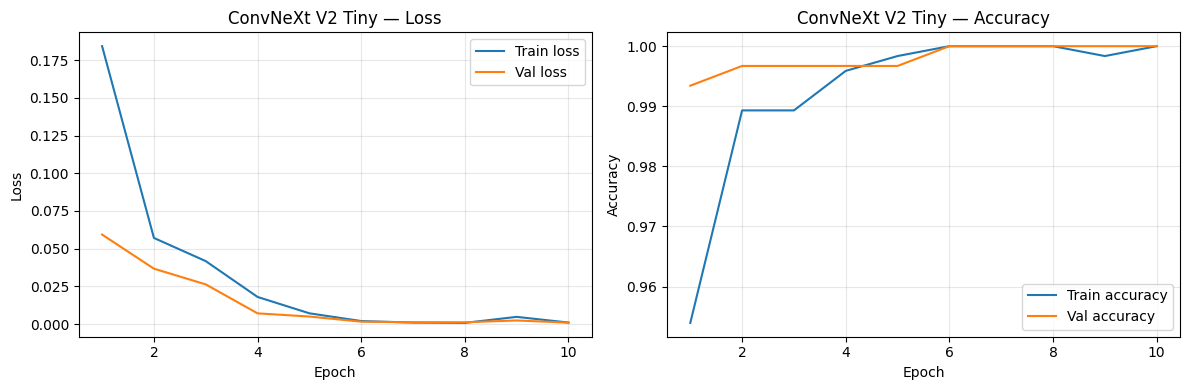

Courbes sauvegardées : /content/drive/MyDrive/TP7+projet/ConvNeXtV2_Tiny_Forest_Fire/figures/convnextv2_tiny_training_curves.png


In [15]:
def plot_history(history_df):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("ConvNeXt V2 Tiny — Loss")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train accuracy")
    plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Val accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("ConvNeXt V2 Tiny — Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    fig_path = os.path.join(FIGURES_DIR, "convnextv2_tiny_training_curves.png")
    plt.savefig(fig_path, dpi=160, bbox_inches="tight")
    plt.show()

    print("Courbes sauvegardées :", fig_path)

plot_history(history_df)


## Évaluation
Analyse des performances du modèle sur l’ensemble de validation.


In [16]:
if best_state is not None:
    model.load_state_dict(best_state["model_state_dict"])

print("Meilleur epoch:", best_epoch)
print("Meilleure val loss:", best_val_loss)

model_path = os.path.join(MODELS_DIR, "convnextv2_tiny_best.pt")
torch.save(best_state, model_path)
print("Meilleur modèle sauvegardé :", model_path)


Meilleur epoch: 10
Meilleure val loss: 0.0008996786732735161
Meilleur modèle sauvegardé : /content/drive/MyDrive/TP7+projet/ConvNeXtV2_Tiny_Forest_Fire/models/convnextv2_tiny_best.pt


In [17]:
val_m, y_val, probs_val = run_one_epoch(
    model,
    val_loader,
    criterion,
    optimizer=None,
    scaler=None,
    label_smoothing=0.0
)

best_th, threshold_df = optimize_threshold(y_val, probs_val)
threshold = float(best_th["threshold"])

threshold_path = os.path.join(RESULTS_DIR, "convnextv2_tiny_thresholds.csv")
threshold_df.to_csv(threshold_path, index=False)

preds_opt = (probs_val >= threshold).astype(int)

cm = confusion_matrix(y_val, preds_opt, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

final_results = {
    "model": "ConvNeXt V2 Tiny",
    "model_name_used": MODEL_NAME_USED,
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "threshold": threshold,
    "val_accuracy": accuracy_score(y_val, preds_opt),
    "val_precision_fire": precision_score(y_val, preds_opt, zero_division=0),
    "val_recall_fire": recall_score(y_val, preds_opt, zero_division=0),
    "val_f1_fire": f1_score(y_val, preds_opt, zero_division=0),
    "val_auc": roc_auc_score(y_val, probs_val),
    "false_negative_fire": int(fn),
    "false_positive_fire": int(fp),
    "true_fire": int(tp + fn),
    "true_nofire": int(tn + fp),
    "time_min": elapsed_min,
    "model_path": model_path,
}

final_df = pd.DataFrame([final_results])
final_path = os.path.join(RESULTS_DIR, "convnextv2_tiny_final_results.csv")
final_df.to_csv(final_path, index=False)

print("Résultats finals :")
display(final_df)

print("\nClassification report :")
print(classification_report(y_val, preds_opt, target_names=["nofire", "fire"], zero_division=0))

print("Thresholds sauvegardés :", threshold_path)
print("Résultats finals sauvegardés :", final_path)


Résultats finals :


,model,model_name_used,best_epoch,best_val_loss,threshold,val_accuracy,val_precision_fire,val_recall_fire,val_f1_fire,val_auc,false_negative_fire,false_positive_fire,true_fire,true_nofire,time_min,model_path
0,ConvNeXt V2 Tiny,convnextv2_tiny.fcmae_ft_in22k_in1k,10,0.0009,0.06,1.0,1.0,1.0,1.0,1.0,0,0,152,152,2.710351,/content/drive/MyDrive/TP7+projet/ConvNeXtV2_T...



Classification report :
              precision    recall  f1-score   support

      nofire       1.00      1.00      1.00       152
        fire       1.00      1.00      1.00       152

    accuracy                           1.00       304
   macro avg       1.00      1.00      1.00       304
weighted avg       1.00      1.00      1.00       304

Thresholds sauvegardés : /content/drive/MyDrive/TP7+projet/ConvNeXtV2_Tiny_Forest_Fire/results/convnextv2_tiny_thresholds.csv
Résultats finals sauvegardés : /content/drive/MyDrive/TP7+projet/ConvNeXtV2_Tiny_Forest_Fire/results/convnextv2_tiny_final_results.csv


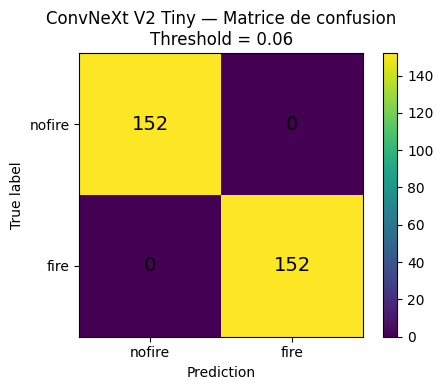

Matrice sauvegardée : /content/drive/MyDrive/TP7+projet/ConvNeXtV2_Tiny_Forest_Fire/figures/convnextv2_tiny_confusion_matrix.png


In [18]:
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f"ConvNeXt V2 Tiny — Matrice de confusion\nThreshold = {threshold}")
plt.xticks([0, 1], ["nofire", "fire"])
plt.yticks([0, 1], ["nofire", "fire"])
plt.xlabel("Prediction")
plt.ylabel("True label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)

plt.colorbar()
plt.tight_layout()

cm_path = os.path.join(FIGURES_DIR, "convnextv2_tiny_confusion_matrix.png")
plt.savefig(cm_path, dpi=160, bbox_inches="tight")
plt.show()

print("Matrice sauvegardée :", cm_path)


In [19]:
last = history_df.iloc[-1]
train_acc = last["train_accuracy"]
val_acc = last["val_accuracy"]
gap = train_acc - val_acc

if history_df["train_accuracy"].max() < 0.85 and history_df["val_accuracy"].max() < 0.85:
    diagnosis = "Underfitting probable : train et validation faibles."
elif gap > 0.08 and train_acc > 0.93:
    diagnosis = "Overfitting probable : train accuracy beaucoup plus haute que validation."
elif history_df["val_loss"].iloc[-1] > history_df["val_loss"].min() * 1.20 and gap > 0.05:
    diagnosis = "Overfitting léger possible : val loss augmente."
else:
    diagnosis = "Bon fit : train et validation sont proches."

print("Train accuracy finale:", round(train_acc, 4))
print("Val accuracy finale:", round(val_acc, 4))
print("Gap train-val:", round(gap, 4))
print("Diagnostic:", diagnosis)


Train accuracy finale: 1.0
Val accuracy finale: 1.0
Gap train-val: 0.0
Diagnostic: Bon fit : train et validation sont proches.


In [20]:
def denormalize(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    img = torch.clamp(img, 0, 1)
    return img.permute(1, 2, 0).numpy()

wrong_idx = np.where(preds_opt != y_val)[0]
print("Nombre d'images mal classées:", len(wrong_idx))

if len(wrong_idx) > 0:
    n = min(len(wrong_idx), 12)
    plt.figure(figsize=(14, 4 * ((n + 3) // 4)))

    for k, idx in enumerate(wrong_idx[:n]):
        img_tensor, label = val_ds[idx]
        prob = probs_val[idx]
        pred = preds_opt[idx]

        plt.subplot((n + 3) // 4, 4, k + 1)
        plt.imshow(denormalize(img_tensor))
        plt.axis("off")
        plt.title(
            f"True: {'fire' if label.item()==1 else 'nofire'}\n"
            f"Pred: {'fire' if pred==1 else 'nofire'} | p_fire={prob:.3f}"
        )

    plt.tight_layout()
    wrong_path = os.path.join(FIGURES_DIR, "convnextv2_tiny_wrong_predictions.png")
    plt.savefig(wrong_path, dpi=160, bbox_inches="tight")
    plt.show()

    print("Images mal classées sauvegardées :", wrong_path)
else:
    print("Aucune erreur sur validation avec le threshold optimisé.")


Nombre d'images mal classées: 0
Aucune erreur sur validation avec le threshold optimisé.


## Résultats / prédictions
Application du modèle sur le dossier `Testing` et sauvegarde des prédictions finales.


In [21]:
tta_transform_original = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

tta_transform_flip = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_ds_tta_1 = ForestFireDataset(val_paths, val_labels, transform=tta_transform_original)
val_ds_tta_2 = ForestFireDataset(val_paths, val_labels, transform=tta_transform_flip)

val_loader_tta_1 = DataLoader(val_ds_tta_1, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
val_loader_tta_2 = DataLoader(val_ds_tta_2, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

_, y_tta, probs_1 = run_one_epoch(model, val_loader_tta_1, criterion, optimizer=None, scaler=None)
_, _, probs_2 = run_one_epoch(model, val_loader_tta_2, criterion, optimizer=None, scaler=None)

probs_tta = (probs_1 + probs_2) / 2.0

best_tta_th, tta_threshold_df = optimize_threshold(y_tta, probs_tta)
tta_threshold = float(best_tta_th["threshold"])
preds_tta = (probs_tta >= tta_threshold).astype(int)

tta_cm = confusion_matrix(y_tta, preds_tta, labels=[0, 1])
tn, fp, fn, tp = tta_cm.ravel()

tta_results = {
    "model": "ConvNeXt V2 Tiny + TTA",
    "threshold": tta_threshold,
    "accuracy": accuracy_score(y_tta, preds_tta),
    "precision_fire": precision_score(y_tta, preds_tta, zero_division=0),
    "recall_fire": recall_score(y_tta, preds_tta, zero_division=0),
    "f1_fire": f1_score(y_tta, preds_tta, zero_division=0),
    "auc": roc_auc_score(y_tta, probs_tta),
    "false_negative_fire": int(fn),
    "false_positive_fire": int(fp),
}

tta_path = os.path.join(RESULTS_DIR, "convnextv2_tiny_tta_results.csv")
pd.DataFrame([tta_results]).to_csv(tta_path, index=False)

print("Résultats TTA :")
display(pd.DataFrame([tta_results]))
print("TTA sauvegardé :", tta_path)


Résultats TTA :


,model,threshold,accuracy,precision_fire,recall_fire,f1_fire,auc,false_negative_fire,false_positive_fire
0,ConvNeXt V2 Tiny + TTA,0.08,1.0,1.0,1.0,1.0,1.0,0,0


TTA sauvegardé : /content/drive/MyDrive/TP7+projet/ConvNeXtV2_Tiny_Forest_Fire/results/convnextv2_tiny_tta_results.csv


In [22]:
def collect_test_images(testing_dir):
    paths = []

    if not os.path.exists(testing_dir):
        print("Dossier Testing introuvable :", testing_dir)
        return np.array(paths)

    for root, dirs, files in os.walk(testing_dir):
        for f in files:
            p = os.path.join(root, f)
            if is_image_file(p):
                paths.append(p)

    return np.array(paths)

test_paths = collect_test_images(TESTING_DIR)
print("Nombre d'images Testing:", len(test_paths))

if len(test_paths) > 0:
    test_ds = ForestFireDataset(test_paths, labels=None, transform=val_transform)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    model.eval()
    rows = []

    with torch.no_grad():
        for images, paths in test_loader:
            images = images.to(DEVICE, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
                logits = model(images)
                if logits.ndim == 1:
                    logits = logits.view(-1, 1)
                probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)

            for p, prob in zip(paths, probs):
                pred = int(prob >= threshold)
                rows.append({
                    "filename": os.path.basename(p),
                    "path": p,
                    "prob_fire": float(prob),
                    "prediction": "fire" if pred == 1 else "nofire",
                    "threshold": threshold,
                    "model": "ConvNeXt V2 Tiny",
                    "model_name_used": MODEL_NAME_USED
                })

    pred_df = pd.DataFrame(rows)
    pred_path = os.path.join(PREDICTIONS_DIR, "testing_predictions_convnextv2_tiny.csv")
    pred_df.to_csv(pred_path, index=False)

    print("Prédictions Testing sauvegardées :", pred_path)
    display(pred_df.head(20))
else:
    print("Aucune image Testing trouvée.")


Nombre d'images Testing: 380
Prédictions Testing sauvegardées : /content/drive/MyDrive/TP7+projet/ConvNeXtV2_Tiny_Forest_Fire/predictions/testing_predictions_convnextv2_tiny.csv


,filename,path,prob_fire,prediction,threshold,model,model_name_used
0,nofire_0781.jpg,/content/Forest Fire Dataset/Testing/nofire_07...,0.000112,nofire,0.06,ConvNeXt V2 Tiny,convnextv2_tiny.fcmae_ft_in22k_in1k
1,nofire_0846.jpg,/content/Forest Fire Dataset/Testing/nofire_08...,0.000068,nofire,0.06,ConvNeXt V2 Tiny,convnextv2_tiny.fcmae_ft_in22k_in1k
2,fire_0620.jpg,/content/Forest Fire Dataset/Testing/fire_0620...,1.000000,fire,0.06,ConvNeXt V2 Tiny,convnextv2_tiny.fcmae_ft_in22k_in1k
3,fire_0769.jpg,/content/Forest Fire Dataset/Testing/fire_0769...,1.000000,fire,0.06,ConvNeXt V2 Tiny,convnextv2_tiny.fcmae_ft_in22k_in1k
4,fire_0935.jpg,/content/Forest Fire Dataset/Testing/fire_0935...,0.999023,fire,0.06,ConvNeXt V2 Tiny,convnextv2_tiny.fcmae_ft_in22k_in1k
5,fire_0709.jpg,/content/Forest Fire Dataset/Testing/fire_0709...,1.000000,fire,0.06,ConvNeXt V2 Tiny,convnextv2_tiny.fcmae_ft_in22k_in1k
6,fire_0525.jpg,/content/Forest Fire Dataset/Testing/fire_0525...,0.999512,fire,0.06,ConvNeXt V2 Tiny,convnextv2_tiny.fcmae_ft_in22k_in1k
7,nofire_0270.jpg,/content/Forest Fire Dataset/Testing/nofire_02...,0.000325,nofire,0.06,ConvNeXt V2 Tiny,convnextv2_tiny.fcmae_ft_in22k_in1k
8,nofire_0476.jpg,/content/Forest Fire Dataset/Testing/nofire_04...,0.000122,nofire,0.06,ConvNeXt V2 Tiny,convnextv2_tiny.fcmae_ft_in22k_in1k
9,fire_0743.jpg,/content/Forest Fire Dataset/Testing/fire_0743...,1.000000,fire,0.06,ConvNeXt V2 Tiny,convnextv2_tiny.fcmae_ft_in22k_in1k


## Conclusion
Le modèle utilisé est **ConvNeXt V2 Tiny pré-entraîné**, un CNN moderne adapté à la classification d’images.

L’évaluation repose sur l’accuracy, la précision, le recall, le F1-score, l’AUC et la matrice de confusion. Pour ce projet, le **recall de la classe `fire`** est particulièrement important, car il faut éviter de manquer une image contenant un incendie.
